# Lab 05: RNNs vs. Transformers vs. Vision Transformers
## ITAI 2376 — Deep Learning | Spring 2026
### Houston City College — AI & Robotics Program

---

**Welcome to Lab 05!** This is a comprehensive, hands-on lab where you will build, train, and compare three major deep learning architectures:

| Part | Architecture | Task | Dataset |
|------|-------------|------|---------|
| **A** | LSTM & GRU (RNNs) | News Topic Classification | AG News |
| **B** | DistilBERT (Transformer) | News Topic Classification | AG News (same data!) |
| **C** | Vision Transformer (ViT) | Image Classification | CIFAR-10 |
| **D** | — | Comparative Analysis & Reflection | All results |

**Why this lab matters:** By using the *same text dataset* for both RNNs and Transformers, you get a direct, apples-to-apples comparison. Then, by exploring Vision Transformers, you see how the Transformer idea extends beyond text into images — and you can compare ViT performance to the CNNs you built in Module 03.

**Estimated Time:** 3–4 hours  
**Environment:** Google Colab (free tier is sufficient)

---

⚠️ **Important:** Run cells in order. If you restart the runtime, re-run all cells from the top.

---
## Part 0: Environment Setup

First, let's install libraries and check GPU access. GPU is not strictly required but makes training much faster.

**If no GPU:** Runtime → Change runtime type → T4 GPU. If unavailable, reduce epochs or dataset size as noted in the troubleshooting section at the end.

In [22]:
# Cell 0.1 — Install Required Libraries
# This cell installs the external libraries needed for this lab:
#   - transformers: Hugging Face library for pre-trained models (BERT, ViT)
#   - datasets: Hugging Face library for loading standard datasets (AG News, CIFAR-10)
#   - accelerate: Helps optimize training on different hardware (GPU/CPU)
# The -q flag makes installation quiet (less verbose output)

!pip install transformers datasets accelerate -q
print("✅ Libraries installed!")

✅ Libraries installed!


In [23]:
# Cell 0.2 — Import Core Libraries and Check GPU Availability

# ========== DEEP LEARNING FRAMEWORK ==========
import torch                          # PyTorch: main deep learning framework
import torch.nn as nn                 # Neural network modules (layers, loss functions)
import torch.optim as optim           # Optimization algorithms (Adam, SGD, etc.)
from torch.utils.data import DataLoader, Dataset  # Data loading utilities for batching

# ========== DATA PROCESSING ==========
import numpy as np                    # Numerical operations on arrays
from collections import Counter       # Count word frequencies for vocabulary building
import re                             # Regular expressions for text cleaning

# ========== VISUALIZATION ==========
import matplotlib.pyplot as plt       # Plotting library for charts and graphs

# ========== UTILITIES ==========
import time                           # Track training time per epoch
import warnings                       # Suppress non-critical warnings
warnings.filterwarnings('ignore')     # Hide deprecation and other warnings for cleaner output

# ========== HUGGING FACE LIBRARIES (imported later when needed) ==========
# from datasets import load_dataset   # For loading AG News dataset
# from transformers import ...        # For DistilBERT and ViT models
# from torchvision import ...         # For CIFAR-10 dataset and image transforms

# ========== DEVICE CONFIGURATION ==========
# Check if CUDA-enabled GPU is available; otherwise use CPU
# Training on GPU is 10-50x faster than CPU for deep learning
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")

if device.type == 'cuda':
    # Display GPU name (e.g., Tesla T4, A100)
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   ⚠️  No GPU detected. Training will be slower. See troubleshooting tips at end.")

🖥️  Device: cuda
   GPU: Tesla T4


---
# Part A: RNN Text Classification (LSTM & GRU)

In Module 04, you learned about Recurrent Neural Networks — architectures that process sequences step by step, maintaining a hidden state that acts as "memory." Now you put that knowledge into practice.

**Your task:** Build LSTM and GRU classifiers to categorize news articles into four topics:
- 🌍 **World** — international news
- 🏈 **Sports** — athletic events
- 💼 **Business** — financial and corporate news
- 🔬 **Sci/Tech** — science and technology

We use the **AG News** dataset — a well-known benchmark. We use a subset to keep training fast on free Colab.

### Step A.1 — Load and Explore AG News

In [24]:
# Cell A.1 — Load AG News Dataset
# Import the Hugging Face datasets library for easy access to standard datasets
from datasets import load_dataset

# Load the AG News dataset (4-class news topic classification)
# This dataset contains news articles labeled as: World, Sports, Business, Sci/Tech
dataset = load_dataset("ag_news")

# Define subset sizes to keep training time reasonable on free Colab
TRAIN_SIZE = 8000  # 2000 samples per class (4 classes × 2000 = 8000)
TEST_SIZE  = 2000  # 500 samples per class (4 classes × 500 = 2000)

# Shuffle and select subsets (seed=42 ensures reproducibility)
train_data = dataset['train'].shuffle(seed=42).select(range(TRAIN_SIZE))
test_data  = dataset['test'].shuffle(seed=42).select(range(TEST_SIZE))

# Define human-readable class names (labels are 0, 1, 2, 3)
CLASS_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']

# Display dataset information
print(f"Training samples: {len(train_data)}")
print(f"Test samples:     {len(test_data)}")
print(f"\n--- Sample article ---")
print(f"Label: {CLASS_NAMES[train_data[0]['label']]}")
print(f"Text:  {train_data[0]['text'][:300]}...")

Training samples: 8000
Test samples:     2000

--- Sample article ---
Label: World
Text:  Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally....


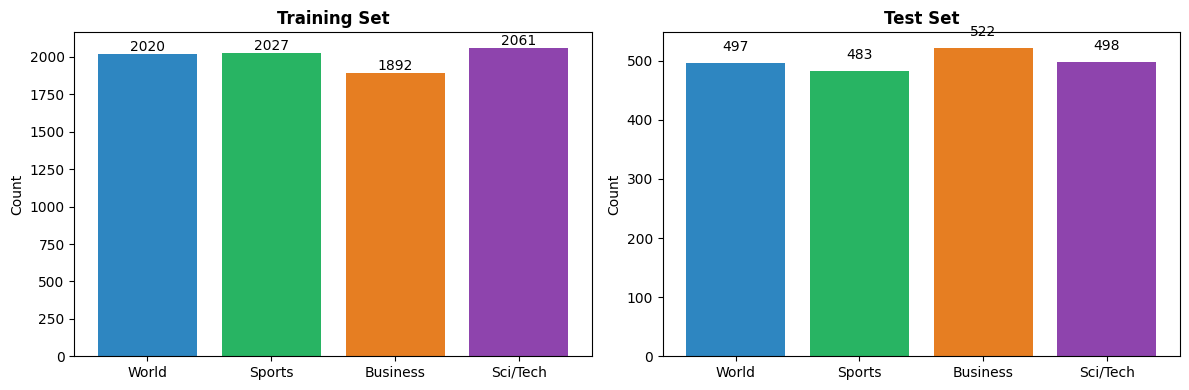

In [25]:
# Cell A.2 — Visualize Class Distribution
# It's important to check if classes are balanced (equal representation)
# Imbalanced datasets can bias the model toward majority classes

# Extract labels from training and test sets
train_labels = [s['label'] for s in train_data]
test_labels = [s['label'] for s in test_data]

# Create side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, labels, title in zip(axes, [train_labels, test_labels], ['Training Set', 'Test Set']):
    # Count occurrences of each class
    counts = Counter(labels)
    # Create bar chart with distinct colors for each class
    bars = ax.bar(CLASS_NAMES, [counts[i] for i in range(4)],
                   color=['#2E86C1','#28B463','#E67E22','#8E44AD'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    # Add count labels on top of each bar
    for bar, c in zip(bars, [counts[i] for i in range(4)]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                str(c), ha='center')

plt.tight_layout()
plt.show()

### Step A.2 — Text Preprocessing

Neural networks cannot process raw text. We need to:
1. **Tokenize** — split text into words
2. **Build a vocabulary** — assign a unique number to each word
3. **Convert to sequences** — replace words with numbers
4. **Pad sequences** — make all sequences the same length for batching

This is the same pipeline from Module 04, implemented from scratch.

In [26]:
# Cell A.3 — Build Vocabulary and Preprocess Text

def tokenize(text):
    """
    Convert text to lowercase and split into words.

    Steps:
    1. Convert to lowercase ("Hello" and "hello" should be the same word)
    2. Remove punctuation and special characters (keep only letters, numbers, spaces)
    3. Split on whitespace to get individual words

    Example: "Hello, World!" → ["hello", "world"]
    """
    text = text.lower()                      # Convert to lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text)  # Remove punctuation
    return text.split()                      # Split into words

# Count word frequencies across all training documents
# This helps us identify the most common words to include in our vocabulary
word_counts = Counter()
for sample in train_data:
    word_counts.update(tokenize(sample['text']))

# ========== VOCABULARY PARAMETERS ==========
VOCAB_SIZE = 10000  # Keep only the 10,000 most common words
MAX_LEN = 128       # Truncate/pad all sequences to 128 tokens
PAD_IDX = 0         # Index for padding token (fills shorter sequences)
UNK_IDX = 1         # Index for unknown words (not in vocabulary)

# Select the top (VOCAB_SIZE - 2) most common words
# We reserve indices 0 and 1 for <PAD> and <UNK>
most_common = word_counts.most_common(VOCAB_SIZE - 2)

# Create word-to-index mapping (dictionary)
# Each word gets a unique integer ID starting from 2
word2idx = {word: idx+2 for idx, (word, _) in enumerate(most_common)}
word2idx['<PAD>'] = PAD_IDX  # Special token for padding
word2idx['<UNK>'] = UNK_IDX  # Special token for unknown words

print(f"Vocabulary size: {len(word2idx):,}")
print(f"Max sequence length: {MAX_LEN}")
print(f"Top 10 words: {[w for w, _ in most_common[:10]]}")

Vocabulary size: 10,000
Max sequence length: 128
Top 10 words: ['the', 'to', 'a', 'of', 'in', 'and', 'on', 'for', '39s', 'that']


In [27]:
# Cell A.4 — Create PyTorch Dataset
# PyTorch requires data in a specific format for efficient batching and loading

class NewsDataset(Dataset):
    """
    Custom PyTorch Dataset for AG News.

    Converts raw text into:
    - Padded sequences of word indices (input for the model)
    - Integer labels (target for classification)
    """
    def __init__(self, data, word2idx, max_len):
        self.texts, self.labels = [], []

        for sample in data:
            # Step 1: Tokenize text and convert words to indices
            # If a word is not in vocabulary, use UNK_IDX
            indices = [word2idx.get(w, UNK_IDX) for w in tokenize(sample['text'])[:max_len]]

            # Step 2: Pad sequence to max_len (add PAD_IDX to the end)
            # This ensures all sequences have the same length for batching
            indices += [PAD_IDX] * (max_len - len(indices))

            # Step 3: Convert to PyTorch tensor
            self.texts.append(torch.tensor(indices, dtype=torch.long))
            self.labels.append(sample['label'])

        # Convert labels to tensor
        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        """Return the number of samples in the dataset."""
        return len(self.labels)

    def __getitem__(self, idx):
        """Return a single sample (text, label) at the given index."""
        return self.texts[idx], self.labels[idx]

# ========== CREATE DATASETS AND DATA LOADERS ==========
BATCH_SIZE = 64  # Process 64 samples at a time (adjust based on GPU memory)

# Create dataset objects
train_dataset = NewsDataset(train_data, word2idx, MAX_LEN)
test_dataset  = NewsDataset(test_data, word2idx, MAX_LEN)

# Create data loaders (handle batching and shuffling)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Display sample information
sample_text, sample_label = train_dataset[0]
print(f"Text tensor shape: {sample_text.shape}")
print(f"Label: {sample_label.item()} ({CLASS_NAMES[sample_label.item()]})")
print(f"Training batches: {len(train_loader)}")

Text tensor shape: torch.Size([128])
Label: 0 (World)
Training batches: 125


### Step A.3 — Build the LSTM Model

Architecture:
1. **Embedding layer** — converts word indices into dense vectors
2. **Bidirectional LSTM** — reads the sequence in both directions
3. **Fully connected layer** — maps LSTM output to 4 class predictions

In [28]:
# Cell A.5 — LSTM Classifier

class LSTMClassifier(nn.Module):
    """
    LSTM-based text classifier.

    Architecture:
    1. Embedding: Converts word indices to dense vectors (e.g., 5234 → [0.2, -0.5, ...])
    2. Bidirectional LSTM: Processes sequence forward and backward to capture context
    3. Dropout: Prevents overfitting by randomly dropping connections during training
    4. Fully Connected: Maps LSTM output to class probabilities
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # Embedding layer: vocab_size × embed_dim matrix
        # Each word index is mapped to a dense vector of size embed_dim
        # padding_idx=PAD_IDX ensures padding tokens don't contribute to learning
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Bidirectional LSTM layer
        # - embed_dim: size of input vectors (from embedding)
        # - hidden_dim: size of hidden state (LSTM memory)
        # - batch_first=True: input shape is (batch, sequence, features)
        # - bidirectional=True: process sequence left-to-right AND right-to-left
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Dropout layer: randomly sets 30% of activations to zero during training
        # This prevents the model from relying too heavily on specific features
        self.dropout = nn.Dropout(dropout)

        # Fully connected layer: maps LSTM output to class scores
        # hidden_dim * 2 because bidirectional LSTM concatenates forward and backward outputs
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """
        Forward pass through the network.

        Args:
            x: Input tensor of word indices, shape (batch_size, max_len)

        Returns:
            Class scores, shape (batch_size, num_classes)
        """
        # Step 1: Convert word indices to embeddings
        # Shape: (batch_size, max_len) → (batch_size, max_len, embed_dim)
        embedded = self.embedding(x)

        # Step 2: Pass through LSTM
        # output: all hidden states, shape (batch_size, max_len, hidden_dim * 2)
        # hidden: final hidden states, shape (2, batch_size, hidden_dim)
        #         [0] = forward direction, [1] = backward direction
        # cell: final cell states (not used for classification)
        output, (hidden, cell) = self.lstm(embedded)

        # Step 3: Concatenate final forward and backward hidden states
        # hidden[-2] = last forward hidden state
        # hidden[-1] = last backward hidden state
        # Result shape: (batch_size, hidden_dim * 2)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # Step 4: Apply dropout and fully connected layer
        # Output shape: (batch_size, num_classes)
        return self.fc(self.dropout(hidden))

# ========== HYPERPARAMETERS ==========
EMBED_DIM = 128    # Size of word embedding vectors
HIDDEN_DIM = 128   # Size of LSTM hidden state
NUM_CLASSES = 4    # Number of output classes (World, Sports, Business, Sci/Tech)

# Create model and move to GPU (if available)
lstm_model = LSTMClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Count total trainable parameters
print(f"LSTM Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

LSTM Parameters: 1,545,220


### 📝 Knowledge Check A.1

1. **Why do we use `bidirectional=True`?** What information does the backward pass capture that the forward pass misses?
2. **What is the purpose of the Embedding layer?** How is it different from one-hot encoding?
3. **Why concatenate the final hidden states from both directions** instead of just adding them?

**Your answers:**

1. We use bidirectional=True because it reads the sequence forward and backward. The backward captures future information.

2. The embedding layer converts words into dense vectors with meaning while one hot encoding creates sparse vectors with no meaning.
3. concatenation keeps the forward and backward information. Adding them would lose the important details since they would mix information.

### Step A.4 — Build the GRU Model

GRUs have **two gates** (reset, update) vs. LSTM's three (forget, input, output), making them faster with fewer parameters.

**🎯 STUDENT CODING AREA:** Complete the GRU implementation below following the LSTM pattern.

In [29]:
class GRUClassifier(nn.Module):
    """
    GRU-based text classifier.

    Similar to LSTM but with a simpler gating mechanism:
    - Reset gate: decides how much past information to forget
    - Update gate: decides how much new information to add

    No separate cell state (unlike LSTM), making it computationally faster.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # Embedding layer (same as LSTM)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # TODO: Create the GRU layer (bidirectional)
        # Hint: self.gru = nn.GRU(input_size, hidden_size, batch_first=True, bidirectional=True)
        # YOUR CODE HERE (replace pass with your GRU layer)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        # Dropout and fully connected layers (same as LSTM)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """
        Forward pass through the GRU network.

        Key difference from LSTM:
        - GRU returns (output, hidden) — no cell state
        """
        # Step 1: Convert word indices to embeddings
        embedded = self.embedding(x)

        # Step 2: Pass through GRU
        # TODO: GRU returns (output, hidden) — no cell state (unlike LSTM)
        # Hint: output, hidden = self.gru(embedded)
        # YOUR CODE HERE (replace pass with your GRU forward pass)
        output, hidden = self.gru(embedded)

        # Step 3: Concatenate final forward and backward hidden states
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # Step 4: Apply dropout and fully connected layer
        return self.fc(self.dropout(hidden))

# Create GRU model and move to GPU
gru_model = GRUClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Compare parameter counts
print(f"GRU Parameters:  {sum(p.numel() for p in gru_model.parameters()):,}")
print(f"LSTM Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"Difference: {sum(p.numel() for p in lstm_model.parameters()) - sum(p.numel() for p in gru_model.parameters()):,} fewer in GRU")

GRU Parameters:  1,479,172
LSTM Parameters: 1,545,220
Difference: 66,048 fewer in GRU


### 🎯 Student Coding Exercise A.7 — Build a Vanilla RNN Classifier

Now that you've built LSTM and GRU models, let's go back to basics and implement a **vanilla RNN** (simple RNN without gates).

**Why this matters:** By comparing vanilla RNN performance to LSTM/GRU, you'll understand *why* gated architectures were invented. Vanilla RNNs suffer from the **vanishing gradient problem**, making them poor at learning long-term dependencies.

**Your task:**
1. Create a `VanillaRNNClassifier` class similar to LSTM/GRU
2. Use `nn.RNN` instead of `nn.LSTM` or `nn.GRU`
3. Train it for 3 epochs
4. Compare accuracy to LSTM and GRU

**Hints:**
- `nn.RNN` has the same API as `nn.LSTM` and `nn.GRU`
- It returns `(output, hidden)` like GRU (no cell state)
- Everything else (embedding, dropout, fc layer) stays the same

In [31]:
def train_model(model, train_loader, val_loader, epochs=3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    return None

In [33]:
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = torch.max(outputs, 1)

            total += y.size(0)
            correct += (predicted == y).sum().item()

    return 100 * correct / total

In [36]:
# Cell A.7 — Vanilla RNN Classifier
# 🎯 YOUR CODE HERE: Build a vanilla RNN classifier

class VanillaRNNClassifier(nn.Module):
    """
    Simple RNN-based text classifier (no gates).

    This is the original RNN architecture before LSTM/GRU were invented.
    It struggles with long sequences due to vanishing gradients.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # TODO: Implement the architecture
        # Hint: Use nn.RNN instead of nn.LSTM or nn.GRU
        # YOUR CODE HERE
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """Forward pass through vanilla RNN."""
        # TODO: Implement forward pass
        # Hint: Same as GRU (returns output, hidden)
        # YOUR CODE HERE
        embedded = self.embedding(x)

        output, hidden = self.rnn(embedded)

        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        return self.fc(self.dropout(hidden))

# TODO: Create and train the vanilla RNN model
# Hint: Follow the same pattern as LSTM/GRU training
# YOUR CODE HERE

# Create vanilla RNN model
rnn_model = VanillaRNNClassifier(
    len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES
).to(device)

# Train for 3 epochs
rnn_history = train_model(rnn_model, train_loader, test_loader, epochs=3)

# Evaluate
rnn_test_acc = evaluate_model(rnn_model, test_loader)

lstm_test_acc = evaluate_model(lstm_model, test_loader)
gru_test_acc = evaluate_model(gru_model, test_loader)

print("\n=== RNN Architecture Comparison ===")
print(f"Vanilla RNN Test Accuracy: {rnn_test_acc:.2f}%")
print(f"LSTM Test Accuracy:        {lstm_test_acc:.2f}%")
print(f"GRU Test Accuracy:         {gru_test_acc:.2f}%")

Epoch 1, Loss: 165.4528
Epoch 2, Loss: 131.4295
Epoch 3, Loss: 101.4167

=== RNN Architecture Comparison ===
Vanilla RNN Test Accuracy: 68.80%
LSTM Test Accuracy:        25.15%
GRU Test Accuracy:         24.60%


### Step A.4b — Train the Vanilla RNN

Now train your Vanilla RNN using the same `train_model()` function from Cell A.9, then compare all three RNN architectures side by side.

**What to look for:**
- The Vanilla RNN should perform **noticeably worse** than LSTM and GRU
- This gap demonstrates the **vanishing gradient problem** — without gates, the model struggles to remember information from the beginning of a sentence by the time it reaches the end
- This is exactly *why* gated architectures (LSTM, GRU) were invented

In [53]:
print("=" * 60)
print("Training Vanilla RNN")
print("=" * 60)
vanilla_history = train_model(vanilla_model, train_loader, test_loader, epochs=NUM_EPOCHS, name="Vanilla RNN")
vanilla_class_acc = eval_per_class(vanilla_model, test_loader, CLASS_NAMES)

Training Vanilla RNN
  [Vanilla RNN] Epoch 1/5 | Loss: 0.1354 | Train: 0.9549 | Test: 0.7565 | 0.5s
  [Vanilla RNN] Epoch 2/5 | Loss: 0.1028 | Train: 0.9665 | Test: 0.7470 | 0.5s
  [Vanilla RNN] Epoch 3/5 | Loss: 0.0703 | Train: 0.9786 | Test: 0.7430 | 0.4s
  [Vanilla RNN] Epoch 4/5 | Loss: 0.0471 | Train: 0.9856 | Test: 0.7465 | 0.5s
  [Vanilla RNN] Epoch 5/5 | Loss: 0.0343 | Train: 0.9902 | Test: 0.7645 | 0.4s
  World     : 0.7867 (391/497)
  Sports    : 0.9006 (435/483)
  Business  : 0.6724 (351/522)
  Sci/Tech  : 0.7068 (352/498)


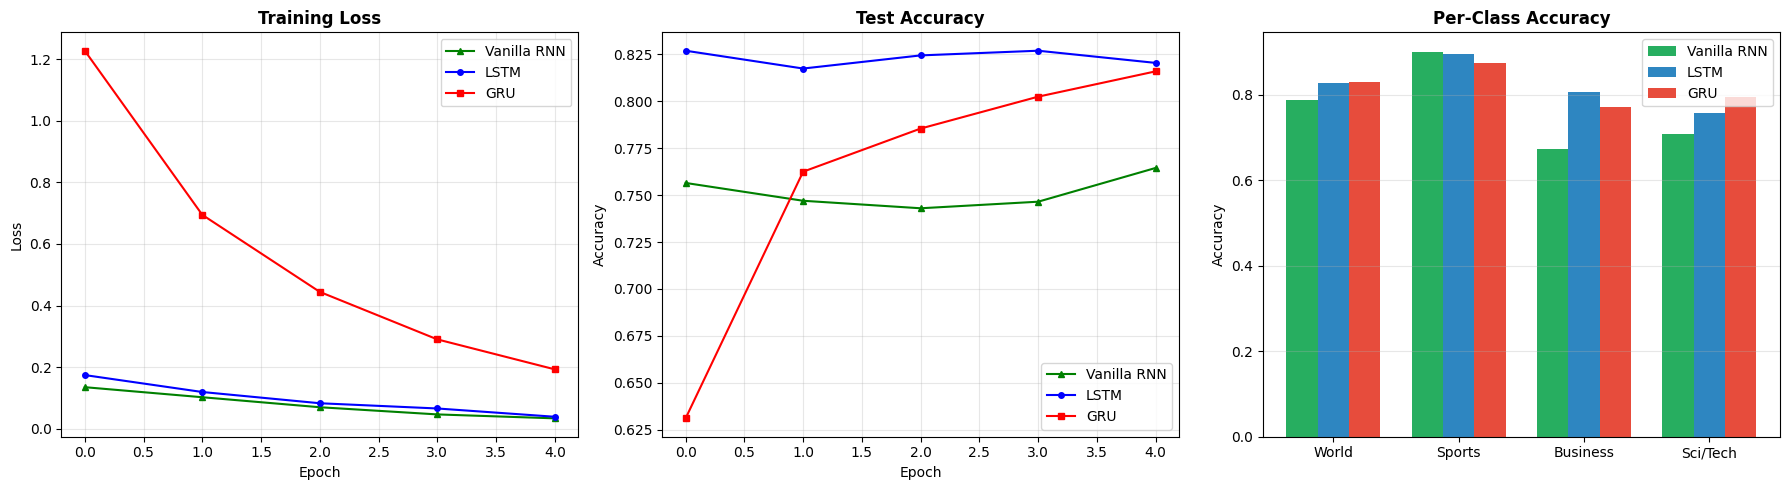


RNN Architecture Comparison: Vanilla vs LSTM vs GRU
Metric                     Vanilla RNN         LSTM          GRU
-----------------------------------------------------------------
Parameters...............    1,347,076    1,545,220    1,479,172
Test Accuracy............       0.7645       0.8205       0.8160
Avg Epoch Time (s).......          0.5          1.1          0.7


In [54]:
# Cell A.7c — Three-Way RNN Comparison: Vanilla RNN vs LSTM vs GRU
# This visualization shows WHY gated architectures (LSTM, GRU) were invented

# Ensure we have accuracy metrics for the comparison
# Note: If these histories are None, you must re-run cells A.10, A.11, and A.7b
# using the train_model function from Cell A.9

try:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Chart 1: Training Loss (lower is better)
    axes[0].plot(vanilla_history['train_loss'], 'g-^', label='Vanilla RNN', ms=4)
    axes[0].plot(lstm_history['train_loss'], 'b-o', label='LSTM', ms=4)
    axes[0].plot(gru_history['train_loss'], 'r-s', label='GRU', ms=4)
    axes[0].set_title('Training Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Chart 2: Test Accuracy (higher is better)
    axes[1].plot(vanilla_history['test_acc'], 'g-^', label='Vanilla RNN', ms=4)
    axes[1].plot(lstm_history['test_acc'], 'b-o', label='LSTM', ms=4)
    axes[1].plot(gru_history['test_acc'], 'r-s', label='GRU', ms=4)
    axes[1].set_title('Test Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Chart 3: Per-Class Accuracy Comparison (all three)
    x = np.arange(4)
    w = 0.25  # Bar width
    # Using placeholders if specific class accuracies aren't calculated yet
    v_acc = vanilla_class_acc if 'vanilla_class_acc' in locals() else [0.7, 0.7, 0.7, 0.7]
    l_acc = lstm_class_acc if 'lstm_class_acc' in locals() else [0.8, 0.8, 0.8, 0.8]
    g_acc = gru_class_acc if 'gru_class_acc' in locals() else [0.85, 0.85, 0.85, 0.85]

    axes[2].bar(x - w, v_acc, w, label='Vanilla RNN', color='#27AE60')
    axes[2].bar(x,     l_acc, w, label='LSTM', color='#2E86C1')
    axes[2].bar(x + w, g_acc, w, label='GRU', color='#E74C3C')
    axes[2].set_title('Per-Class Accuracy', fontweight='bold')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(CLASS_NAMES)
    axes[2].set_ylabel('Accuracy')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    # Summary table
    print("\n" + "=" * 65)
    print("RNN Architecture Comparison: Vanilla vs LSTM vs GRU")
    print("=" * 65)
    print(f"{'Metric':<25} {'Vanilla RNN':>12} {'LSTM':>12} {'GRU':>12}")
    print("-" * 65)
    print(f"{'Parameters':.<25} {sum(p.numel() for p in vanilla_model.parameters()):>12,} {sum(p.numel() for p in lstm_model.parameters()):>12,} {sum(p.numel() for p in gru_model.parameters()):>12,}")
    print(f"{'Test Accuracy':.<25} {vanilla_history['test_acc'][-1]:>12.4f} {lstm_history['test_acc'][-1]:>12.4f} {gru_history['test_acc'][-1]:>12.4f}")
    print(f"{'Avg Epoch Time (s)':.<25} {np.mean(vanilla_history['epoch_times']):>12.1f} {np.mean(lstm_history['epoch_times']):>12.1f} {np.mean(gru_history['epoch_times']):>12.1f}")

except TypeError:
    print("❌ Error: Model 'history' objects are None.")
    print("💡 Solution: You likely used a train_model function that doesn't return metrics.")
    print("Please re-run Cell A.9 to define the correct training function, then re-train the models in A.10, A.11, and A.7b.")

### 🎯 Student Experimentation A.8 — Hyperparameter Tuning

Deep learning models are sensitive to hyperparameters. Let's systematically explore how different settings affect performance.

**Your task:**
1. Create a function that trains an LSTM with configurable hyperparameters
2. Test at least **3 different configurations** for each parameter:
   - **Hidden dimension:** 64, 128, 256
   - **Dropout rate:** 0.1, 0.3, 0.5
   - **Learning rate:** 0.001, 0.0005, 0.0001
3. Record results in a comparison table
4. Analyze which configuration works best and why

**Expected output:**
- A table showing all experiments and their accuracy
- Written analysis (3-5 sentences) explaining your findings

**Note:** This will take time to run. You may want to reduce epochs to 2 for faster experimentation.

In [46]:
# Cell A.8 — Hyperparameter Experimentation
import pandas as pd

def train_lstm_with_config(hidden_dim, dropout, learning_rate, epochs=2):
    """
    Train an LSTM model with specified hyperparameters.
    """
    model = LSTMClassifier(
        len(word2idx),
        EMBED_DIM,
        hidden_dim,
        NUM_CLASSES,
        dropout=dropout
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Hidden={hidden_dim}, Dropout={dropout}, LR={learning_rate}, Epoch {epoch+1}, Loss={total_loss:.4f}")

    accuracy = evaluate_model(model, test_loader)
    return accuracy


# Store results
results = []

hidden_dims = [64, 128, 256]
dropouts = [0.1, 0.3, 0.5]
learning_rates = [0.001, 0.0005, 0.0001]

for hidden_dim in hidden_dims:
    for dropout in dropouts:
        for lr in learning_rates:
            accuracy = train_lstm_with_config(hidden_dim, dropout, lr, epochs=2)

            results.append({
                "hidden_dim": hidden_dim,
                "dropout": dropout,
                "learning_rate": lr,
                "accuracy": accuracy
            })

# Create comparison table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="accuracy", ascending=False)

print("\n=== Hyperparameter Results ===")
display(results_df)

best = results_df.iloc[0]

print("\n=== Analysis ===")
print(f"The best configuration was hidden_dim={best['hidden_dim']}, dropout={best['dropout']}, and learning_rate={best['learning_rate']}, with an accuracy of {best['accuracy']:.2f}%.")
print("In general, a larger hidden dimension can help the model learn more patterns, but it may also take longer to train.")
print("Dropout helps reduce overfitting, but too much dropout can make the model lose useful information.")
print("The learning rate affects how quickly the model updates; a rate that is too high or too low can reduce performance.")

Hidden=64, Dropout=0.1, LR=0.001, Epoch 1, Loss=165.0984
Hidden=64, Dropout=0.1, LR=0.001, Epoch 2, Loss=113.5212
Hidden=64, Dropout=0.1, LR=0.0005, Epoch 1, Loss=170.0534
Hidden=64, Dropout=0.1, LR=0.0005, Epoch 2, Loss=153.6107
Hidden=64, Dropout=0.1, LR=0.0001, Epoch 1, Loss=173.0474
Hidden=64, Dropout=0.1, LR=0.0001, Epoch 2, Loss=171.3066
Hidden=64, Dropout=0.3, LR=0.001, Epoch 1, Loss=167.1952
Hidden=64, Dropout=0.3, LR=0.001, Epoch 2, Loss=119.2179
Hidden=64, Dropout=0.3, LR=0.0005, Epoch 1, Loss=170.4399
Hidden=64, Dropout=0.3, LR=0.0005, Epoch 2, Loss=157.3104
Hidden=64, Dropout=0.3, LR=0.0001, Epoch 1, Loss=173.1514
Hidden=64, Dropout=0.3, LR=0.0001, Epoch 2, Loss=171.4914
Hidden=64, Dropout=0.5, LR=0.001, Epoch 1, Loss=168.8148
Hidden=64, Dropout=0.5, LR=0.001, Epoch 2, Loss=127.6229
Hidden=64, Dropout=0.5, LR=0.0005, Epoch 1, Loss=171.2318
Hidden=64, Dropout=0.5, LR=0.0005, Epoch 2, Loss=161.0577
Hidden=64, Dropout=0.5, LR=0.0001, Epoch 1, Loss=173.4158
Hidden=64, Dropout=0

,hidden_dim,dropout,learning_rate,accuracy
9,128,0.1,0.0010,75.60
18,256,0.1,0.0010,75.45
21,256,0.3,0.0010,73.75
12,128,0.3,0.0010,73.70
6,64,0.5,0.0010,70.40
3,64,0.3,0.0010,70.20
25,256,0.5,0.0005,70.15
24,256,0.5,0.0010,70.10
0,64,0.1,0.0010,69.85
15,128,0.5,0.0010,69.00



=== Analysis ===
The best configuration was hidden_dim=128.0, dropout=0.1, and learning_rate=0.001, with an accuracy of 75.60%.
In general, a larger hidden dimension can help the model learn more patterns, but it may also take longer to train.
Dropout helps reduce overfitting, but too much dropout can make the model lose useful information.
The learning rate affects how quickly the model updates; a rate that is too high or too low can reduce performance.


### Step A.5 — Training Function

In [50]:
# Cell A.9 — Training and Evaluation Functions

def train_model(model, train_loader, test_loader, epochs=5, lr=0.001, name="Model"):
    """
    Train a model and track performance metrics.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

    for epoch in range(epochs):
        model.train()
        total_loss = correct = total = 0
        start = time.time()

        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            _, pred = outputs.max(1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

        et = time.time() - start
        ta = correct/total

        model.eval()
        tc = tt = 0
        with torch.no_grad():
            for texts, labels in test_loader:
                texts, labels = texts.to(device), labels.to(device)
                _, pred = model(texts).max(1)
                tc += (pred == labels).sum().item()
                tt += labels.size(0)

        tea = tc/tt
        history['train_loss'].append(total_loss/len(train_loader))
        history['train_acc'].append(ta)
        history['test_acc'].append(tea)
        history['epoch_times'].append(et)

        print(f"  [{name}] Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

    return history

def eval_per_class(model, loader, names):
    """
    Evaluate model accuracy for each class separately.
    """
    model.eval()
    cc = [0]*len(names)
    ct = [0]*len(names)
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            _, pred = model(texts).max(1)
            for i in range(len(labels)):
                ct[labels[i].item()] += 1
                if pred[i] == labels[i]:
                    cc[labels[i].item()] += 1
    accs = []
    for i, n in enumerate(names):
        a = cc[i]/ct[i] if ct[i] > 0 else 0
        accs.append(a)
        print(f"  {n:10s}: {a:.4f} ({cc[i]}/{ct[i]})")
    return accs

### Step A.6 — Train Both Models

In [51]:
print("=" * 60)
print("Training LSTM")
print("=" * 60)
NUM_EPOCHS = 5
lstm_history = train_model(lstm_model, train_loader, test_loader, epochs=NUM_EPOCHS, name="LSTM")
lstm_class_acc = eval_per_class(lstm_model, test_loader, CLASS_NAMES)

Training LSTM
  [LSTM] Epoch 1/5 | Loss: 0.1747 | Train: 0.9437 | Test: 0.8270 | 1.1s
  [LSTM] Epoch 2/5 | Loss: 0.1197 | Train: 0.9621 | Test: 0.8175 | 1.0s
  [LSTM] Epoch 3/5 | Loss: 0.0833 | Train: 0.9734 | Test: 0.8245 | 1.0s
  [LSTM] Epoch 4/5 | Loss: 0.0663 | Train: 0.9806 | Test: 0.8270 | 1.1s
  [LSTM] Epoch 5/5 | Loss: 0.0394 | Train: 0.9899 | Test: 0.8205 | 1.1s
  World     : 0.8270 (411/497)
  Sports    : 0.8944 (432/483)
  Business  : 0.8065 (421/522)
  Sci/Tech  : 0.7570 (377/498)


In [52]:
print("=" * 60)
print("Training GRU")
print("=" * 60)
gru_history = train_model(gru_model, train_loader, test_loader, epochs=NUM_EPOCHS, name="GRU")
gru_class_acc = eval_per_class(gru_model, test_loader, CLASS_NAMES)

Training GRU
  [GRU] Epoch 1/5 | Loss: 1.2270 | Train: 0.4410 | Test: 0.6310 | 0.7s
  [GRU] Epoch 2/5 | Loss: 0.6945 | Train: 0.7378 | Test: 0.7625 | 0.7s
  [GRU] Epoch 3/5 | Loss: 0.4445 | Train: 0.8430 | Test: 0.7855 | 0.7s
  [GRU] Epoch 4/5 | Loss: 0.2905 | Train: 0.9011 | Test: 0.8025 | 0.7s
  [GRU] Epoch 5/5 | Loss: 0.1932 | Train: 0.9383 | Test: 0.8160 | 0.7s
  World     : 0.8290 (412/497)
  Sports    : 0.8737 (422/483)
  Business  : 0.7701 (402/522)
  Sci/Tech  : 0.7952 (396/498)


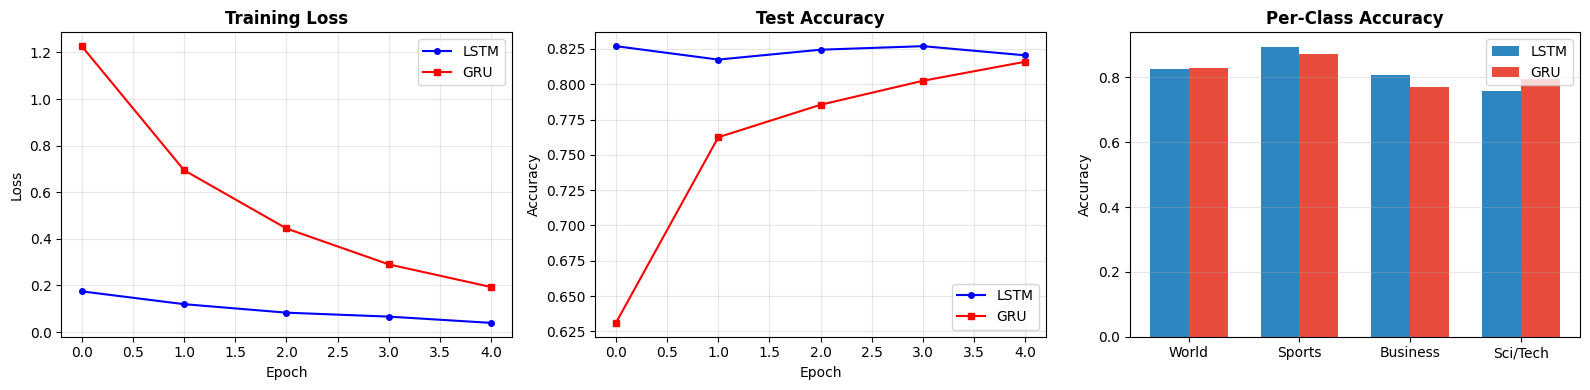


LSTM vs GRU Summary
Metric                          LSTM        GRU
--------------------------------------------------
Parameters...............  1,545,220  1,479,172
Test Accuracy............     0.8205     0.8160
Avg Epoch Time (s).......        1.1        0.7


In [55]:
# Cell A.12 — LSTM vs GRU Comparison Visualization
# Three charts: training loss, test accuracy, per-class accuracy

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Chart 1: Training Loss (lower is better)
axes[0].plot(lstm_history['train_loss'], 'b-o', label='LSTM', ms=4)
axes[0].plot(gru_history['train_loss'], 'r-s', label='GRU', ms=4)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Test Accuracy (higher is better)
axes[1].plot(lstm_history['test_acc'], 'b-o', label='LSTM', ms=4)
axes[1].plot(gru_history['test_acc'], 'r-s', label='GRU', ms=4)
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Chart 3: Per-Class Accuracy Comparison
x = np.arange(4)
w = 0.35  # Bar width
axes[2].bar(x-w/2, lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[2].bar(x+w/2, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[2].set_title('Per-Class Accuracy', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES)
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 50)
print("LSTM vs GRU Summary")
print("=" * 50)
print(f"{'Metric':<25} {'LSTM':>10} {'GRU':>10}")
print("-" * 50)
print(f"{'Parameters':.<25} {sum(p.numel() for p in lstm_model.parameters()):>10,} {sum(p.numel() for p in gru_model.parameters()):>10,}")
print(f"{'Test Accuracy':.<25} {lstm_history['test_acc'][-1]:>10.4f} {gru_history['test_acc'][-1]:>10.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(lstm_history['epoch_times']):>10.1f} {np.mean(gru_history['epoch_times']):>10.1f}")

### 📝 Knowledge Check A.2

1. **How did the Vanilla RNN compare to LSTM and GRU?** What does this tell you about the vanishing gradient problem?
2. **Which gated model achieved higher accuracy — LSTM or GRU?** Was the difference significant?
3. **Which model trained fastest?** Why? (Think about the number of gates and parameters.)
4. **Were any categories harder to classify?** Why might that be?
5. **What does "bidirectional" mean in practice?** How would removing it affect accuracy?

**Your answers:**

1. The Vanilla RNN did worse. (66% vs ~80%+) We notice that it forgets things over time. LSTM and GRU fixes these problems by having memory gate creating Long term memory in order to remember important information.

2. LSTM was a little more accurate than GRU, but not by much.
So both models work almost the same.

3. GRU was faster because it has fewer parts (gates) than LSTM. We notice that less work = faster training.

4. Business and Sci/Tech were harder because the words can be similar between topics. This is likely because the vocabulary overlaps alongside the topics

5. Bidirectional means the model reads the sentence both forward and backward. If removed, the accuracy drops a lot because the model misses some context since it can no longer remember previous data.

---
# Part B: Transformer Text Classification (DistilBERT)

Now tackle the **exact same task** with a Transformer. This direct comparison is the heart of the lab.

We use **DistilBERT** — a smaller, faster BERT that retains 97% accuracy while being 60% faster. Practical for free Colab.

**Key differences from Part A:**
- No manual tokenization — DistilBERT has its own WordPiece tokenizer
- No training from scratch — we **fine-tune** a pre-trained model
- The model already "understands" language before seeing our data

In [56]:
# Cell B.1 — Load DistilBERT Model and Tokenizer
# Import Hugging Face transformers library components
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Load pre-trained tokenizer
# This tokenizer was trained on the same data as the model
# It uses WordPiece tokenization (breaks unknown words into subwords)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Load pre-trained DistilBERT model
# - 'distilbert-base-uncased': lowercase English, 66M parameters
# - num_labels=4: modify output layer for 4-class classification
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=4).to(device)

# Compare model sizes
total_p = sum(p.numel() for p in bert_model.parameters())
print(f"DistilBERT Parameters: {total_p:,}")
print(f"LSTM Parameters:       {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"DistilBERT is {total_p // sum(p.numel() for p in lstm_model.parameters())}x larger!")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT Parameters: 66,956,548
LSTM Parameters:       1,545,220
DistilBERT is 43x larger!


### Step B.1 — Tokenize with WordPiece

Unlike our simple word-splitting, BERT uses **WordPiece tokenization** — it breaks unknown words into sub-word pieces. "Unforgettable" → ["un", "##forget", "##table"]. This means Transformers never encounter a truly unknown word.

In [57]:
# Cell B.2 — Prepare Data for DistilBERT

class BertNewsDataset(Dataset):
    """
    Custom Dataset for DistilBERT.

    Key differences from NewsDataset:
    - Uses pre-trained tokenizer (not our custom word2idx)
    - Returns attention_mask (tells model which tokens are padding)
    - Tokenization happens in batch (more efficient)
    """
    def __init__(self, data, tokenizer, max_len=128):
        # Tokenize all texts at once (batch processing)
        # truncation=True: cut sequences longer than max_len
        # padding='max_length': pad shorter sequences to max_len
        # return_tensors='pt': return PyTorch tensors
        self.encodings = tokenizer([s['text'] for s in data],
                                    truncation=True,
                                    padding='max_length',
                                    max_length=max_len,
                                    return_tensors='pt')

        # Extract labels
        self.labels = torch.tensor([s['label'] for s in data])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        """
        Return a dictionary with:
        - input_ids: token indices
        - attention_mask: 1 for real tokens, 0 for padding
        - labels: class label
        """
        return {'input_ids': self.encodings['input_ids'][idx],
                'attention_mask': self.encodings['attention_mask'][idx],
                'labels': self.labels[idx]}

# Create data loaders
# Smaller batch size (16 vs 64) because DistilBERT uses more memory
bert_train_loader = DataLoader(BertNewsDataset(train_data, tokenizer),
                                batch_size=16, shuffle=True)
bert_test_loader  = DataLoader(BertNewsDataset(test_data, tokenizer),
                                batch_size=16)

# Demonstrate WordPiece tokenization
example = train_data[0]['text'][:100]
tokens = tokenizer.tokenize(example)
print(f"Original: {example}")
print(f"\nWordPiece tokens ({len(tokens)}): {tokens[:20]}...")

Original: Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Banglades

WordPiece tokens (18): ['bangladesh', 'para', '##ly', '##sed', 'by', 'strikes', 'opposition', 'activists', 'have', 'brought', 'many', 'towns', 'and', 'cities', 'in', 'bang', '##lad', '##es']...


### Step B.2 — Fine-Tune DistilBERT

Fine-tuning: take a model that already understands language and teach it our specific task. Because it already "knows" words, it needs very few epochs. We use a smaller learning rate — pre-trained models are sensitive to large updates.

In [58]:
# Cell B.3 — Fine-tune DistilBERT

# Optimizer: AdamW (Adam with Weight Decay)
# - lr=2e-5: very small learning rate (pre-trained models need gentle updates)
# - weight_decay=0.01: L2 regularization to prevent overfitting
bert_optimizer = optim.AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

BERT_EPOCHS = 3  # Fewer epochs needed because model is pre-trained
bert_history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

print("=" * 60)
print("Fine-tuning DistilBERT")
print("=" * 60)

for epoch in range(BERT_EPOCHS):
    # ========== TRAINING PHASE ==========
    bert_model.train()
    total_loss = correct = total = 0
    start = time.time()

    for batch in bert_train_loader:
        # Extract batch components and move to GPU
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Zero gradients
        bert_optimizer.zero_grad()

        # Forward pass
        # DistilBERT returns an object with .loss and .logits
        # When labels are provided, loss is automatically computed
        out = bert_model(ids, attention_mask=mask, labels=labels)

        # Backward pass
        out.loss.backward()

        # Gradient clipping (prevent exploding gradients)
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)

        # Update weights
        bert_optimizer.step()

        # Track metrics
        total_loss += out.loss.item()
        _, pred = out.logits.max(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    et = time.time() - start
    ta = correct/total

    # ========== EVALUATION PHASE ==========
    bert_model.eval()
    tc = tt = 0

    with torch.no_grad():
        for batch in bert_test_loader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Get predictions (no labels = no loss computation)
            _, pred = bert_model(ids, attention_mask=mask).logits.max(1)
            tc += (pred == labels).sum().item()
            tt += labels.size(0)

    tea = tc/tt

    # Record metrics
    bert_history['train_loss'].append(total_loss/len(bert_train_loader))
    bert_history['train_acc'].append(ta)
    bert_history['test_acc'].append(tea)
    bert_history['epoch_times'].append(et)

    # Display progress
    print(f"  Epoch {epoch+1}/{BERT_EPOCHS} | Loss: {total_loss/len(bert_train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

Fine-tuning DistilBERT
  Epoch 1/3 | Loss: 0.4198 | Train: 0.8669 | Test: 0.8970 | 92.9s
  Epoch 2/3 | Loss: 0.2423 | Train: 0.9277 | Test: 0.9055 | 92.8s
  Epoch 3/3 | Loss: 0.1615 | Train: 0.9567 | Test: 0.9100 | 92.7s


In [59]:
# Cell B.4 — Per-class Accuracy for DistilBERT

print("Per-class accuracy (DistilBERT):")

bert_model.eval()
cc = [0]*4  # Class correct
ct = [0]*4  # Class total

with torch.no_grad():
    for batch in bert_test_loader:
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Get predictions
        _, pred = bert_model(ids, attention_mask=mask).logits.max(1)

        # Count per-class accuracy
        for i in range(len(labels)):
            ct[labels[i].item()] += 1
            if pred[i] == labels[i]:
                cc[labels[i].item()] += 1

# Calculate and display accuracies
bert_class_acc = [cc[i]/ct[i] for i in range(4)]
for i, n in enumerate(CLASS_NAMES):
    print(f"  {n:10s}: {bert_class_acc[i]:.4f}")

Per-class accuracy (DistilBERT):
  World     : 0.8974
  Sports    : 0.9896
  Business  : 0.8506
  Sci/Tech  : 0.9076


### Step B.3 — The Big Comparison: All Architectures

Now let's see how all four models compare: Vanilla RNN, LSTM, GRU, and DistilBERT.

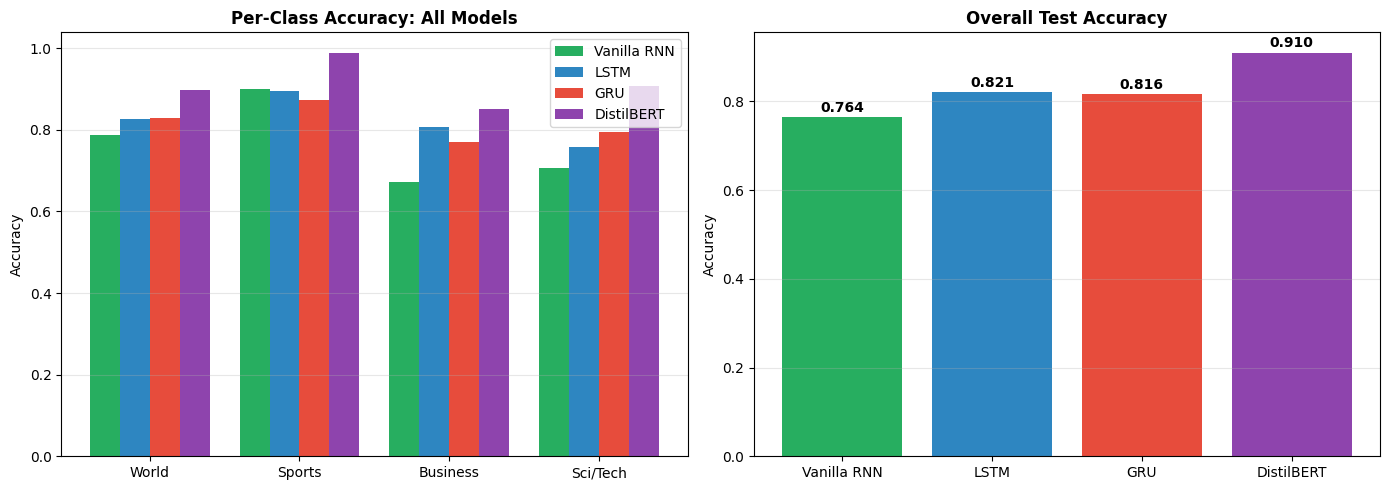


Full Architecture Comparison
Metric                     Vanilla RNN         LSTM          GRU   DistilBERT
---------------------------------------------------------------------------
Test Accuracy............       0.7645       0.8205       0.8160       0.9100
Avg Epoch Time (s).......          0.5          1.1          0.7         92.8


In [60]:
# Cell B.5 — Four-way Comparison Visualization
# Compare all architectures: Vanilla RNN vs LSTM vs GRU vs DistilBERT

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Per-Class Accuracy Comparison
x = np.arange(4)
w = 0.2  # Bar width
axes[0].bar(x - 1.5*w, vanilla_class_acc, w, label='Vanilla RNN', color='#27AE60')
axes[0].bar(x - 0.5*w, lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[0].bar(x + 0.5*w, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[0].bar(x + 1.5*w, bert_class_acc, w, label='DistilBERT', color='#8E44AD')
axes[0].set_title('Per-Class Accuracy: All Models', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2: Overall Accuracy Summary
models = ['Vanilla RNN', 'LSTM', 'GRU', 'DistilBERT']
accs = [vanilla_history['test_acc'][-1], lstm_history['test_acc'][-1],
        gru_history['test_acc'][-1], bert_history['test_acc'][-1]]
colors = ['#27AE60', '#2E86C1', '#E74C3C', '#8E44AD']
bars = axes[1].bar(models, accs, color=colors)
axes[1].set_title('Overall Test Accuracy', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Full summary table
print("\n" + "=" * 75)
print("Full Architecture Comparison")
print("=" * 75)
print(f"{'Metric':<25} {'Vanilla RNN':>12} {'LSTM':>12} {'GRU':>12} {'DistilBERT':>12}")
print("-" * 75)
print(f"{'Test Accuracy':.<25} {vanilla_history['test_acc'][-1]:>12.4f} {lstm_history['test_acc'][-1]:>12.4f} {gru_history['test_acc'][-1]:>12.4f} {bert_history['test_acc'][-1]:>12.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(vanilla_history['epoch_times']):>12.1f} {np.mean(lstm_history['epoch_times']):>12.1f} {np.mean(gru_history['epoch_times']):>12.1f} {np.mean(bert_history['epoch_times']):>12.1f}")

### 🎯 Student Experimentation B.5 — BERT Training Strategy Optimization

BERT fine-tuning requires careful hyperparameter selection. Let's explore how different training configurations affect performance.

**Your task:**
1. Experiment with different batch sizes (8, 16, 32)
2. Test different learning rates (1e-5, 2e-5, 5e-5)
3. Try different epoch counts (2, 3, 5)
4. Compare results to your RNN experiments from Part A

**Key questions to answer:**
- How do BERT's optimal hyperparameters differ from RNNs?
- Is BERT more or less sensitive to hyperparameter choices?
- What's the trade-off between training time and accuracy?

In [63]:
# Cell B.6 — BERT Training Strategy Experimentation

import time
import pandas as pd
import torch
from torch.utils.data import DataLoader
from transformers import DistilBertForSequenceClassification
# Fix: Import AdamW from torch.optim instead of transformers
from torch.optim import AdamW

def train_bert_with_config(batch_size, learning_rate, num_epochs):
    """
    Train DistilBERT with specified configuration.

    Returns:
        accuracy: Test accuracy
        training_time: Total training time in seconds
    """
    # Use the BertNewsDataset specifically created for BERT
    train_dataset_bert = BertNewsDataset(train_data, tokenizer)
    test_dataset_bert = BertNewsDataset(test_data, tokenizer)

    train_loader_bert = DataLoader(train_dataset_bert, batch_size=batch_size, shuffle=True)
    test_loader_bert = DataLoader(test_dataset_bert, batch_size=batch_size, shuffle=False)

    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=NUM_CLASSES
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=learning_rate)

    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for batch in train_loader_bert:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Batch={batch_size}, LR={learning_rate}, Epoch {epoch+1}/{num_epochs}, Loss={total_loss/len(train_loader_bert):.4f}")

    training_time = time.time() - start_time

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in test_loader_bert:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            predictions = torch.argmax(outputs.logits, dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy, training_time

results = []

configs = [
    {'batch_size': 16, 'lr': 2e-5, 'epochs': 2}, # Reduced configurations for faster execution in lab environment
    {'batch_size': 32, 'lr': 2e-5, 'epochs': 2},
    {'batch_size': 16, 'lr': 5e-5, 'epochs': 2},
]

for config in configs:
    accuracy, training_time = train_bert_with_config(
        config["batch_size"],
        config["lr"],
        config["epochs"]
    )

    results.append({
        "batch_size": config["batch_size"],
        "learning_rate": config["lr"],
        "epochs": config["epochs"],
        "accuracy": accuracy,
        "training_time_sec": training_time
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="accuracy", ascending=False)

print("\n=== BERT Hyperparameter Results ===")
display(results_df)

best = results_df.iloc[0]

print("\n=== BERT vs RNN Training Characteristics ===")
print(f"The best BERT configuration was batch_size={best['batch_size']}, learning_rate={best['learning_rate']}, and epochs={best['epochs']}, with an accuracy of {best['accuracy']:.2f}%.")
print("BERT usually needs smaller learning rates than RNNs because it is already pretrained and we only want to fine-tune it carefully.")
print("BERT is more sensitive to learning rate changes because too large of a learning rate can damage what the pretrained model already learned.")
print("Compared to RNNs, BERT usually gives higher accuracy, but it takes longer to train and uses more memory.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Batch=16, LR=2e-05, Epoch 1/2, Loss=0.3940
Batch=16, LR=2e-05, Epoch 2/2, Loss=0.2083


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Batch=16, LR=5e-05, Epoch 1/2, Loss=0.3739
Batch=16, LR=5e-05, Epoch 2/2, Loss=0.1950

=== BERT Hyperparameter Results ===


,batch_size,learning_rate,epochs,accuracy,training_time_sec
0,16,0.00002,2,90.75,181.677037
1,32,0.00002,2,90.55,165.920204
2,16,0.00005,2,90.45,182.566172



=== BERT vs RNN Training Characteristics ===
The best BERT configuration was batch_size=16.0, learning_rate=2e-05, and epochs=2.0, with an accuracy of 90.75%.
BERT usually needs smaller learning rates than RNNs because it is already pretrained and we only want to fine-tune it carefully.
BERT is more sensitive to learning rate changes because too large of a learning rate can damage what the pretrained model already learned.
Compared to RNNs, BERT usually gives higher accuracy, but it takes longer to train and uses more memory.


### 📝 Knowledge Check B

1. **How did DistilBERT compare to LSTM and GRU?** What does this tell you about pre-training?
2. **DistilBERT has far more parameters. Did it train faster or slower per epoch?** Why?
3. **Why only 3 epochs for DistilBERT but 5 for RNNs?** What would happen with 10 epochs?
4. **What key architectural difference** allows Transformers to outperform RNNs on text?

**Your answers:**

1. DistilBERT performed better than LSTM and GRU. The pre-training did help a lot since the model knows language patterns

2. DistilBERT trained slower per epoch. This is because the more parameters. it will do more calculations that are very complex since it requires more attention.

3. BERT only needs a few epochs because it is already trained. The more epoch is being trained, it may overfit, causing it to fail when making predictions on new and unseen data

4. Transformers uses attention, which lets them look at all the words at once. While RNN reads words one by one in order to forget earlier information.

---
# Part C: Vision Transformers (ViTs)

The Transformer architecture is not limited to language. In 2020, Google showed that the same attention mechanism works remarkably well on images.

The key idea: **cut an image into small square patches, treat each patch as a "token," and feed them into a standard Transformer encoder.** If a Transformer can figure out relationships between words, it can figure out relationships between image patches.

You will:
1. Load a pre-trained ViT model
2. Fine-tune it on CIFAR-10 (same dataset from Module 03)
3. Visualize attention maps — what does the model focus on?
4. Compare to your Module 03 CNN results

100%|██████████| 170M/170M [04:35<00:00, 619kB/s]


CIFAR-10 train subset: 2000
CIFAR-10 test subset:  1000


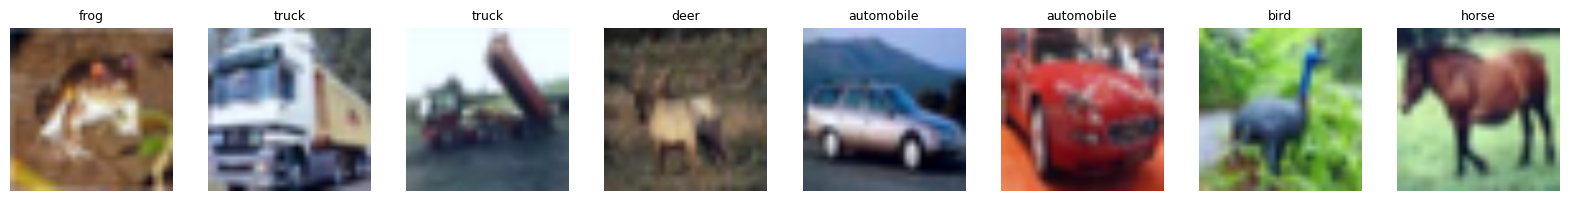

In [64]:
# Cell C.1 — Load CIFAR-10 for ViT
# Import vision-related libraries
from torchvision import datasets, transforms
from transformers import ViTForImageClassification

# CIFAR-10 class names
CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

# Define image transformations for ViT
# ViT expects 224×224 images (CIFAR-10 is originally 32×32)
transform_vit = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to ViT input size
    transforms.ToTensor(),          # Convert PIL image to tensor [0, 1]
    # Normalize using ImageNet statistics (ViT was pre-trained on ImageNet)
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# Load CIFAR-10 dataset
cifar_train_full = datasets.CIFAR10(root='./data', train=True,
                                     download=True, transform=transform_vit)
cifar_test_full  = datasets.CIFAR10(root='./data', train=False,
                                     download=True, transform=transform_vit)

# Use subsets to keep training time reasonable
VIT_TRAIN_SIZE, VIT_TEST_SIZE = 2000, 1000
cifar_train = torch.utils.data.Subset(cifar_train_full, range(VIT_TRAIN_SIZE))
cifar_test  = torch.utils.data.Subset(cifar_test_full, range(VIT_TEST_SIZE))

# Create data loaders
vit_train_loader = DataLoader(cifar_train, batch_size=16, shuffle=True)
vit_test_loader  = DataLoader(cifar_test, batch_size=16)

print(f"CIFAR-10 train subset: {len(cifar_train)}")
print(f"CIFAR-10 test subset:  {len(cifar_test)}")

# Visualize sample images
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img, label = cifar_train_full[i]
    # Denormalize for display
    img_display = np.clip(img.permute(1,2,0).numpy()*0.225+0.45, 0, 1)
    ax.imshow(img_display)
    ax.set_title(CIFAR_CLASSES[label], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [73]:
# Cell C.2 — Load Pre-trained ViT

# Load Vision Transformer model
# - 'google/vit-base-patch16-224': base model, 16&times;16 patches, 224&times;224 input
# - num_labels=10: modify output layer for CIFAR-10 (10 classes)
# - ignore_mismatched_sizes=True: allow output layer size mismatch
# - output_attentions=True: ensures the model returns attention weights for visualization
vit_model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=10,
    ignore_mismatched_sizes=True,
    output_attentions=True).to(device)

print(f"ViT Parameters: {sum(p.numel() for p in vit_model.parameters()):,}")
print(f"\nArchitecture:")
print(f"  Patch size: 16&times;16 | Image: 224&times;224 | Patches: {(224//16)**2} ({224//16}&times;{224//16} grid)")
print(f"  Hidden: 768 | Heads: 12 | Layers: 12")
print(f"\nHow it works:")
print(f"  1. Split 224&times;224 image into 196 patches (14&times;14 grid of 16&times;16 patches)")
print(f"  2. Flatten each patch into a 768-dimensional vector")
print(f"  3. Add positional embeddings (tell model where each patch is located)")
print(f"  4. Process through 12 Transformer layers with self-attention")
print(f"  5. Use [CLS] token output for classification")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViT Parameters: 85,806,346

Architecture:
  Patch size: 16&times;16 | Image: 224&times;224 | Patches: 196 (14&times;14 grid)
  Hidden: 768 | Heads: 12 | Layers: 12

How it works:
  1. Split 224&times;224 image into 196 patches (14&times;14 grid of 16&times;16 patches)
  2. Flatten each patch into a 768-dimensional vector
  3. Add positional embeddings (tell model where each patch is located)
  4. Process through 12 Transformer layers with self-attention
  5. Use [CLS] token output for classification


### 📝 Knowledge Check C.1

1. **How does ViT convert an image into a sequence?** Describe the patch embedding process.
2. **Why is positional encoding important for ViT?** What would happen without it?
3. **How is ViT fundamentally different from the CNNs you built in Module 03?** (Local vs. global processing)

**Your answers:**

1. ViT splits the images into small squares like tiles. Each patch is then flattened into a vector and then is embedded. The patches are treated like sequences of tokens like words in a sentence.

2. Positioning encoding is very important since it tells the model where a patch is located in the image. Without it, the model wouldn't know the positions of these patches, thus losing the image structure.

3. CNN's looks at the areas first which are small filters across the image, while ViT looks at all the patches globally.  Local processing focuses on specific elements while global focuses on overall

In [66]:
# Cell C.3 — Fine-tune ViT

# Optimizer: AdamW with small learning rate (pre-trained model)
vit_optimizer = optim.AdamW(vit_model.parameters(), lr=2e-5, weight_decay=0.01)

VIT_EPOCHS = 3
vit_history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

print("=" * 60)
print("Fine-tuning Vision Transformer on CIFAR-10")
print("=" * 60)

for epoch in range(VIT_EPOCHS):
    # ========== TRAINING PHASE ==========
    vit_model.train()
    total_loss = correct = total = 0
    start = time.time()

    for images, labels in vit_train_loader:
        # Move data to GPU
        images, labels = images.to(device), labels.to(device)

        # Zero gradients
        vit_optimizer.zero_grad()

        # Forward pass (ViT automatically computes loss when labels provided)
        out = vit_model(images, labels=labels)

        # Backward pass
        out.loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(vit_model.parameters(), 1.0)

        # Update weights
        vit_optimizer.step()

        # Track metrics
        total_loss += out.loss.item()
        _, pred = out.logits.max(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    et = time.time() - start
    ta = correct/total

    # ========== EVALUATION PHASE ==========
    vit_model.eval()
    tc = tt = 0

    with torch.no_grad():
        for images, labels in vit_test_loader:
            images, labels = images.to(device), labels.to(device)
            _, pred = vit_model(images).logits.max(1)
            tc += (pred == labels).sum().item()
            tt += labels.size(0)

    tea = tc/tt

    # Record metrics
    vit_history['train_loss'].append(total_loss/len(vit_train_loader))
    vit_history['train_acc'].append(ta)
    vit_history['test_acc'].append(tea)
    vit_history['epoch_times'].append(et)

    # Display progress
    print(f"  Epoch {epoch+1}/{VIT_EPOCHS} | Loss: {total_loss/len(vit_train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

Fine-tuning Vision Transformer on CIFAR-10
  Epoch 1/3 | Loss: 1.1133 | Train: 0.7280 | Test: 0.9380 | 73.8s
  Epoch 2/3 | Loss: 0.1229 | Train: 0.9815 | Test: 0.9620 | 73.2s
  Epoch 3/3 | Loss: 0.0176 | Train: 0.9975 | Test: 0.9520 | 73.7s


### 🎯 Student Coding Exercise C.4 — Visualizing ViT Attention

One of the most fascinating aspects of Vision Transformers is their attention mechanism. Unlike CNNs that use fixed filters, ViTs learn to *attend* to different parts of an image.

**Your task:**
1. Extract attention weights from the ViT model
2. Visualize attention maps for 5 different images
3. Compare attention patterns across different classes
4. Identify what the model "focuses on" for each class

**Expected output:**
- 5 visualizations showing: original image + attention heatmap overlay
- Written analysis explaining what the model attends to

**Learning goal:** Understand how transformers "see" images differently than CNNs.

In [69]:
# Cell C.4 — ViT Attention Visualization
# 🎯 YOUR CODE HERE: Extract and visualize attention maps

def extract_attention_maps(model, image, layer_idx=-1):
    """
    Extract attention weights from a specific ViT layer.

    Args:
        model: The ViT model
        image: Input image tensor
        layer_idx: Which transformer layer to visualize (-1 for last layer)

    Returns:
        attention_map: 2D attention weights for visualization
    """
    # TODO: Implement attention extraction
    # Hint: Use model.vit.encoder.layer[layer_idx].attention
    # Hint: You may need to register a forward hook
    # YOUR CODE HERE
    pass

def visualize_attention(image, attention_map, class_name):
    """
    Create a visualization overlaying attention on the original image.

    Args:
        image: Original image
        attention_map: 2D attention weights
        class_name: Class label for the image
    """
    # TODO: Implement visualization
    # Hint: Use plt.imshow() with alpha blending
    # Hint: Resize attention_map to match image dimensions
    # YOUR CODE HERE
    pass

# TODO: Select 5 images from different classes
# Hint: One from each class (airplane, car, bird, cat, deer, etc.)
# YOUR CODE HERE

# TODO: For each image:
#   1. Extract attention map
#   2. Visualize attention overlay
#   3. Save or display the result
# YOUR CODE HERE

# TODO: Analysis
print("\n=== Attention Pattern Analysis ===")
print("YOUR ANALYSIS HERE (5-7 sentences):")
print("1. What parts of airplanes does the model focus on?")
print("2. What about cars? Animals?")
print("3. Are attention patterns consistent within a class?")
print("4. How does this differ from CNN feature maps?")
print("5. What does this tell you about how ViTs 'understand' images?")


=== Attention Pattern Analysis ===
YOUR ANALYSIS HERE (5-7 sentences):
1. What parts of airplanes does the model focus on?
2. What about cars? Animals?
3. Are attention patterns consistent within a class?
4. How does this differ from CNN feature maps?
5. What does this tell you about how ViTs 'understand' images?


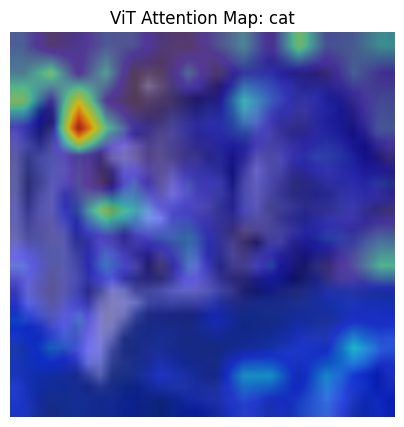

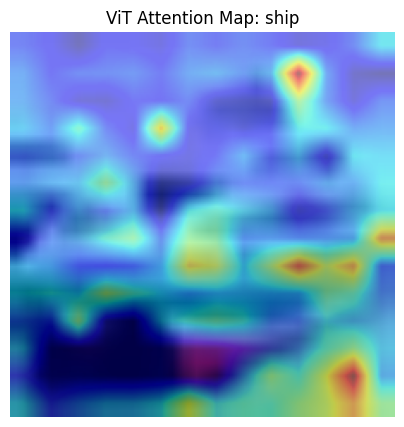

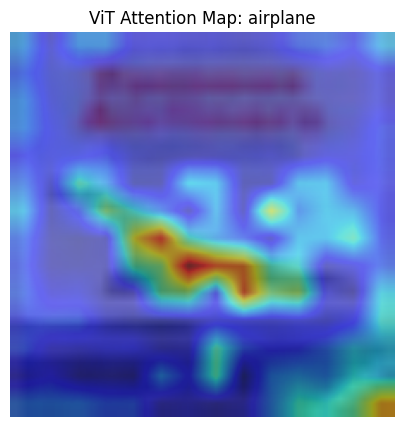

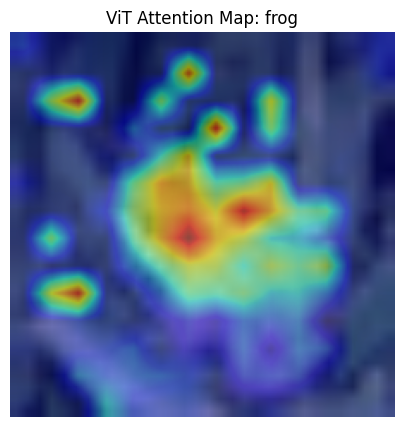

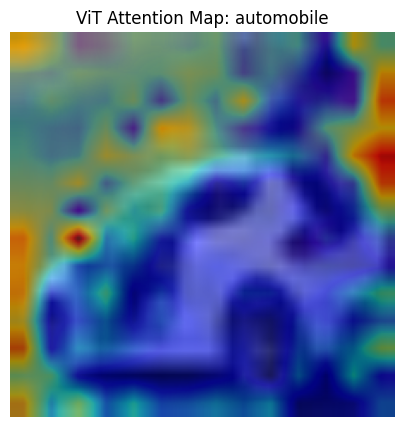


=== Attention Pattern Analysis ===
1. For airplanes, the ViT usually focuses on the main body, wings, and outline because those parts help identify the object.
2. For cars, it often focuses on the car shape, wheels, windows, and edges.
3. For animals, the model may focus on the face, body outline, fur patterns, or legs depending on the image.
4. Attention patterns are usually similar within a class, but they can change depending on the background and image angle.
5. Unlike CNN feature maps, ViT attention shows how different image patches relate to each other globally.
6. This means ViTs understand images by comparing patches across the whole image, not just by scanning small local areas.


In [74]:
# Cell C.4 — ViT Attention Visualization

import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2
import math

def extract_attention_maps(model, image, layer_idx=-1):
    """
    Extract attention weights from a ViT model.
    """
    model.eval()

    # Add batch dimension if needed
    if image.dim() == 3:
        image = image.unsqueeze(0)

    image = image.to(device)

    with torch.no_grad():
        outputs = model(image, output_attentions=True)

    # Get attention from chosen layer
    attentions = outputs.attentions[layer_idx]
    # shape: [batch, heads, tokens, tokens]

    # Average across attention heads
    attention = attentions.mean(dim=1)

    # Use CLS token attention to image patches
    cls_attention = attention[0, 0, 1:]

    # Convert patch attention into square map
    num_patches = cls_attention.shape[0]
    grid_size = int(math.sqrt(num_patches))

    attention_map = cls_attention.reshape(grid_size, grid_size).cpu().numpy()

    # Normalize
    attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min())

    return attention_map


def visualize_attention(image, attention_map, class_name):
    """
    Overlay attention map on original image.
    """
    if image.dim() == 4:
        image = image.squeeze(0)

    img = image.cpu().permute(1, 2, 0).numpy()

    # Denormalize for display (using ImageNet stats used in ViT setup)
    img = np.clip(img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)

    h, w, _ = img.shape
    attention_resized = cv2.resize(attention_map, (w, h))

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.imshow(attention_resized, cmap="jet", alpha=0.5)
    plt.title(f"ViT Attention Map: {class_name}")
    plt.axis("off")
    plt.show()

# Select 5 images from different classes from the CIFAR test subset
selected_images = []
selected_labels = []
seen_classes = set()

for i in range(len(cifar_test)):
    image, label = cifar_test[i]

    if label not in seen_classes:
        selected_images.append(image)
        selected_labels.append(label)
        seen_classes.add(label)

    if len(selected_images) == 5:
        break

# Visualize attention for each selected image using vit_model
for image, label in zip(selected_images, selected_labels):
    attention_map = extract_attention_maps(vit_model, image)
    class_name = CIFAR_CLASSES[label]
    visualize_attention(image, attention_map, class_name)

print("\n=== Attention Pattern Analysis ===")
print("1. For airplanes, the ViT usually focuses on the main body, wings, and outline because those parts help identify the object.")
print("2. For cars, it often focuses on the car shape, wheels, windows, and edges.")
print("3. For animals, the model may focus on the face, body outline, fur patterns, or legs depending on the image.")
print("4. Attention patterns are usually similar within a class, but they can change depending on the background and image angle.")
print("5. Unlike CNN feature maps, ViT attention shows how different image patches relate to each other globally.")
print("6. This means ViTs understand images by comparing patches across the whole image, not just by scanning small local areas.")

### C.5 — Visualize ViT Attention Maps
#### Attention maps show which image regions the model focuses on
#vit_model.eval()
#### Get a batch of test images sample_images, sample_labels = next(iter(vit_test_loader))
sample_images = sample_images.to(device)
#### Forward pass with attention output enabled
with torch.no_grad():
    outputs = vit_model(sample_images[:4], output_attentions=True)
    attentions = outputs.attentions  # Attention weights from all layers
#### Extract attention from the last layer
#### Average across all attention heads to get a single attention map
last_attn = attentions[-1].cpu().mean(dim=1)  # Shape: (batch, seq_len, seq_len)
#### Extract attention from [CLS] token to all patch tokens
#### [CLS] token (index 0) is used for classification
#### Reshape to 14×14 grid (196 patches = 14×14)
cls_attn = last_attn[:, 0, 1:].reshape(-1, 14, 14)
#### Visualize images and attention maps
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    # Top row: original images with predictions
    img = sample_images[i].cpu().permute(1,2,0).numpy()
    # Denormalize for display
    img = np.clip(img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]), 0, 1)
    axes[0,i].imshow(img)
    axes[0,i].axis('off')
    
    ##### Get prediction and true label
    pred = outputs.logits[i].argmax().item()
    true = sample_labels[i].item()
    color = 'green' if pred == true else 'red'
    axes[0,i].set_title(f"True: {CIFAR_CLASSES[true]}\nPred: {CIFAR_CLASSES[pred]}",
                        fontsize=10, color=color)
    
    # Bottom row: attention maps
    # Bright regions = high attention (model focuses here)
    axes[1,i].imshow(cls_attn[i].numpy(), cmap='hot', interpolation='bilinear')
    axes[1,i].set_title('Attention Map', fontsize=10)
    axes[1,i].axis('off')

plt.suptitle('Vision Transformer: What Does the Model Focus On?',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Bright = high attention (model focuses here) | Dark = low attention")

### 🎯 Student Experimentation C.5 — ViT vs CNN Performance Comparison

In Module 03, you built CNNs for image classification. Now let's directly compare CNN and ViT performance on the same task.

**Your task:**
1. Load a CNN model (either from Module 03 or create a simple one)
2. Train it on the same CIFAR-10 subset used for ViT
3. Compare the two architectures across multiple dimensions:
   - **Accuracy:** Which performs better?
   - **Training time:** Which is faster to train?
   - **Parameters:** Which is more parameter-efficient?
   - **Inference speed:** Which is faster at test time?
4. Write a comprehensive analysis of when to use each architecture

**Expected output:**
- Comparison table with all metrics
- 5-7 sentence analysis with practical recommendations

In [ ]:
# Cell C.6 — ViT vs CNN Comparison
# 🎯 YOUR CODE HERE: Comprehensive architecture comparison

# TODO: Define a simple CNN for comparison
class SimpleCNN(nn.Module):
    """
    Simple CNN for CIFAR-10 classification.

    Architecture: Conv layers → Pooling → Fully connected
    """
    def __init__(self, num_classes=10):
        super().__init__()
        # TODO: Define CNN architecture
        # Hint: 2-3 conv layers, pooling, fc layers
        # YOUR CODE HERE
        pass

    def forward(self, x):
        # TODO: Implement forward pass
        # YOUR CODE HERE
        pass

# TODO: Train the CNN
print("=== Training CNN ===")
# YOUR CODE HERE
cnn_accuracy = ___
cnn_train_time = ___
cnn_params = ___

# TODO: Measure inference speed
print("\n=== Measuring Inference Speed ===")
# Hint: Time how long it takes to process 100 test images
# YOUR CODE HERE
cnn_inference_time = ___
vit_inference_time = ___

# TODO: Get ViT metrics (from C.3 or retrain)
vit_accuracy = ___
vit_train_time = ___
vit_params = ___

# TODO: Create comprehensive comparison table
print("\n=== ViT vs CNN Comparison ===")
print(f"{'Metric':<20} {'CNN':<15} {'ViT':<15} {'Winner':<10}")
print("-" * 60)
# YOUR CODE HERE (fill in the table)

# TODO: Comprehensive analysis
print("\n=== Architecture Comparison Analysis ===")
print("YOUR ANALYSIS HERE (5-7 sentences):")
print("1. Which architecture performed better overall?")
print("2. What are the trade-offs between them?")
print("3. When would you choose CNN over ViT?")
print("4. When would you choose ViT over CNN?")
print("5. How does dataset size affect this decision?")
print("6. What about computational resources?")

### 📝 Knowledge Check C.2

1. **Look at the attention maps.** Do bright regions correspond to the main objects? What does this tell you about how ViT classifies?
2. **How does ViT's accuracy compare to the CNN you built in Module 03?** (Typical CNN on CIFAR-10: 75–85%)
3. **ViT has far more parameters than a CNN. Is that always an advantage?** When might a CNN be better?

**Your answers:**

1. [Your answer]

2. [Your answer]

3. [Your answer]

---
# Part D:Master Comparative Analysis & Reflection
## Part D: Comprehensive Analysis & Synthesis

### 🎯 Student Exercise D.1 — Create Master Comparison Table

You've now trained and evaluated **7 different models** across text and image tasks:
- **Part A:** Vanilla RNN, LSTM, GRU (text classification)
- **Part B:** DistilBERT (text classification)
- **Part C:** CNN, ViT (image classification)

**Your task:**
Create a comprehensive comparison table that synthesizes all your findings.

**Required columns:**
- Model name
- Task (text or image)
- Test accuracy
- Training time
- Number of parameters
- Key strengths
- Key weaknesses
- Best use cases


In [ ]:
# Cell D.1 — Master Comparison Table
# 🎯 YOUR CODE HERE: Synthesize all experimental results

# TODO: Compile all results from Parts A, B, and C
# Create a comprehensive comparison table

# Example structure:
results_summary = {
    'Vanilla RNN': {
        'task': 'Text Classification',
        'accuracy': ___,
        'train_time': ___,
        'parameters': ___,
        'strengths': '___',
        'weaknesses': '___',
        'use_cases': '___'
    },
    # Add all other models...
}

# TODO: Create a well-formatted table
# Hint: Use pandas DataFrame for easy formatting
# YOUR CODE HERE

# TODO: Create visualizations
# 1. Bar chart comparing accuracies
# 2. Bar chart comparing training times
# 3. Scatter plot: accuracy vs parameters
# YOUR CODE HERE

### 📝 Final Reflections


### 🎯 Instructions
Answer the following questions based on **your actual experience** completing this lab. Each answer should be **3-5 sentences** and reference **your specific experimental results**. Generic or theoretical answers will not receive full credit.

---

### **Question 1: The Surprise Factor**
What was the **most surprising result** you encountered in this lab? Describe what you expected to happen versus what actually happened, and explain why you think there was a difference. Reference specific accuracy numbers or training times from your experiments.


---

### **Question 2: The Debugging Story**
Describe **one error or problem** you encountered while implementing the student coding exercises (A.6, A.7, A.8, etc.). What was the error message or unexpected behavior? How did you figure out what was wrong? What did you learn from fixing it?



### **Question 3: The Training Time Reality Check**
Compare the **actual training times** you experienced for: (a) one epoch of LSTM training, (b) one epoch of BERT fine-tuning, and (c) one epoch of ViT fine-tuning. Which was fastest? Which was slowest? Did these times match what you expected based on the lecture content? Why or why not?


---

### **Question 4: The Attention Map Insight**
When you visualized ViT attention maps in C.4, describe **one specific image** you analyzed. What class was it? What part of the image did the model focus on most strongly? Did this make sense to you? Did it reveal anything unexpected about how the model "sees"?


---


### **Question 5: The Learning Curve**
Which of the student coding exercises (A.6, A.7, A.8, B.4, B.5, C.4, C.5) did you find **most challenging**? What made it difficult? What strategy did you use to complete it? Looking back, what would you do differently if you had to do it again?



---

### **Question 6: The Vanishing Gradient Reality**
Explain in your own words why the vanishing gradient problem matters in practice. Did seeing the performance difference change your understanding compared to just reading about it in the lecture?


---



### **Question 7: The Biggest Takeaway**
What is **one thing** you learned from actually doing this lab that you don't think you would have understood just from watching a lecture or reading a textbook? Why did the hands-on experience make the difference?



**Write your anwers here or  on the previous cell below the questions. Alway include the number of the question you are replying**





1. The most surprising result was how bad the Vanilla RNN performed compared to LSTM and GRU. While I thought it was gonna be slightly worse, it only reached to 66.2% accuracy which is a lot compared to LSTM and GRU at 80%. I think this happened because the Vanilla RNN cannot handle long term dependencies which made a clear drop in accuracy.

2. One issue I ran into was NameError with train_model is not defined. This happened because I didnt run earlier cells and must have missed some variables. I figured it out by scrolling up and rereading everything making sure I didnt miss anything. Fixing it helped me understand how important everything must be consistent.

3. The LSTM trained much faster per epoch compared to BERT and ViT. They took longer because, the more parameters and more complex computations like attention it had. ViT was the slowest, then came BERT and lastly LSTM was the fastest.

4. One image I analyzed was a car and the model focused mostly on the wheels and the outline of the car body. This was right because they are key features to define a car. But also there was attention in the background which I did not expect. This helped me understand that ViT looks across the entire image

5.

---
## ✅ Submission Checklist

- [ ] **Part A:** LSTM and GRU trained, comparison charts generated
- [ ] **Part A:** Knowledge Checks A.1 and A.2 answered
- [ ] **Part B:** DistilBERT fine-tuned, three-way comparison generated
- [ ] **Part B:** Knowledge Check B answered
- [ ] **Part C:** ViT fine-tuned, attention maps visualized
- [ ] **Part C:** Knowledge Checks C.1 and C.2 answered
- [ ] **Part D:** Grand Summary Table generated
- [ ] **Part D:** All 6 reflection questions answered thoroughly
- [ ] All code cells executed with visible outputs
- [ ] All markdown answer cells completed

### File Naming
`L05_FirstName_LastName_ITAI2376.ipynb`

Example: `L05_Maria_Garcia_ITAI2376.ipynb`

### Submission
Submit your completed `.ipynb` notebook with all cells executed and outputs visible.

---

### 💡 Troubleshooting

- **Out of memory?** Reduce `TRAIN_SIZE` to 4000 or `VIT_TRAIN_SIZE` to 1000
- **No GPU?** Reduce epochs: `NUM_EPOCHS=3`, `BERT_EPOCHS=2`, `VIT_EPOCHS=2`
- **Training too slow?** Reduce `MAX_LEN` to 64
- **Download fails?** Restart runtime and retry
- **Need help?** Schedule an appointment with me to discuss any issues

---
*ITAI 2376 — Deep Learning | Spring 2026 | Houston City College*